**Pós-Graduação UEA Ciência de Dados 2025**

**Disciplina:** Programação para Ciência de Dados

**Professor:** Tiago de Melo

**Etapa 2:** Modelo de Classificação de Genêro

**Dataset:** https://www.kaggle.com/datasets/elakiricoder/gender-classification-dataset

**Equipe:**
  Eduardo, Gabriel, Jhonata, Leticia, Volnei

# **- Modelo usando scikit-learn (Python)**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Import dataset
gender_classification_df = pd.read_csv("gender_classification_v7.csv")
gender_classification_df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [ ]:
# Show dataset structure
print(f"{gender_classification_df.info()}\n")

print("Missing values for each column:")
for column_name in gender_classification_df.columns:
    print(f"\t{column_name}: {gender_classification_df[column_name].isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB
None

Missing values for each column:
	long_hair: 0
	forehead_width_cm: 0
	forehead_height_cm: 0
	nose_wide: 0
	nose_long: 0
	lips_thin: 0
	distance_nose_to_lip_long: 0
	gender: 0


In [ ]:
# Describe forehead width feature
print(f"{gender_classification_df.forehead_width_cm.describe()}\n")

gender_forehead_width_cm = (
    gender_classification_df[gender_classification_df.gender == "Male"].forehead_width_cm.values.tolist(),
    gender_classification_df[gender_classification_df.gender == "Female"].forehead_width_cm.values.tolist()
)

pd.DataFrame(gender_forehead_width_cm).head()

count    5001.000000
mean       13.181484
std         1.107128
min        11.400000
25%        12.200000
50%        13.100000
75%        14.000000
max        15.500000
Name: forehead_width_cm, dtype: float64



,0,1,2,3,4,5,6,7,8,9,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,11.8,11.8,14.4,13.0,15.3,12.5,15.5,14.7,14.5,12.5,...,14.1,13.8,12.0,11.7,12.1,14.1,12.9,12.3,15.4,NaN
1,14.0,13.5,13.0,11.9,12.1,14.2,14.0,11.9,12.9,14.2,...,14.0,12.9,12.1,12.6,12.1,11.6,13.6,11.9,12.9,13.2


In [ ]:
# Describe forehead heigth feature
print(f"{gender_classification_df.forehead_height_cm.describe()}\n")

gender_forehead_height_cm = (
    gender_classification_df[gender_classification_df.gender == "Male"].forehead_height_cm.values.tolist(),
    gender_classification_df[gender_classification_df.gender == "Female"].forehead_height_cm.values.tolist()
)

pd.DataFrame(gender_forehead_height_cm).head()

count    5001.000000
mean        5.946311
std         0.541268
min         5.100000
25%         5.500000
50%         5.900000
75%         6.400000
max         7.100000
Name: forehead_height_cm, dtype: float64



,0,1,2,3,4,5,6,7,8,9,...,2491,2492,2493,2494,2495,2496,2497,2498,2499,2500
0,6.1,6.3,6.1,6.8,6.2,5.4,5.8,5.2,6.7,5.2,...,5.2,6.4,6.1,6.1,6.2,7.0,7.0,6.9,5.4,NaN
1,5.4,5.9,5.2,5.4,5.4,6.5,5.9,5.2,6.4,5.3,...,5.3,6.1,5.8,5.7,5.8,5.9,5.1,5.4,5.7,6.2


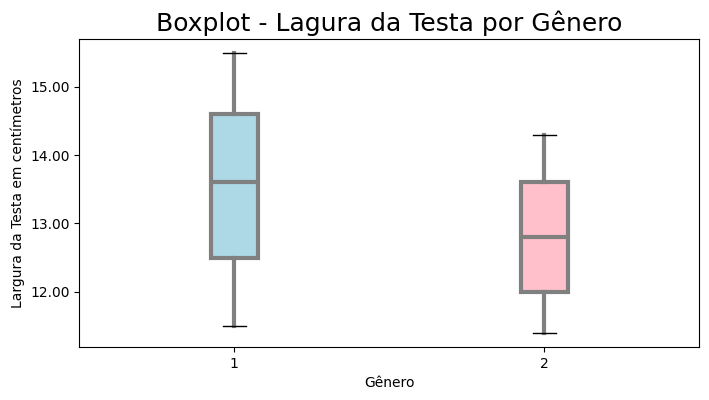

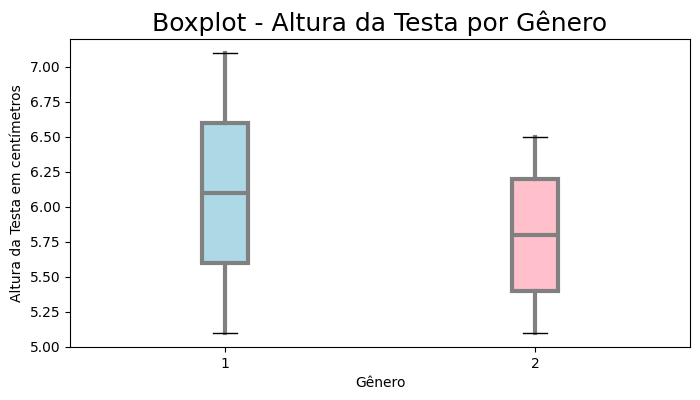

In [ ]:
def render_box_plot(x, title, xlabel, ylabel):
    plt.figure(figsize=(8, 4))

    bplots = plt.boxplot(x, vert=1, patch_artist=True)

    colors = ("lightblue", "pink")

    for box, color in zip(bplots["boxes"], colors):
        box.set(color="gray", linewidth=3)
        box.set(facecolor=color)

    for whisker in bplots["whiskers"]:
        whisker.set(color="gray", linewidth=3)

    for median in bplots["medians"]:
        median.set(color="gray", linewidth=3)

    plt.title(title, loc="center", fontsize=18)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.gca().yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

    plt.show()

# Box Plots for forehead dimensions
render_box_plot(
    x=gender_forehead_width_cm,
    title="Boxplot - Lagura da Testa por Gênero",
    xlabel="Gênero",
    ylabel="Largura da Testa em centímetros"
)

render_box_plot(
    x=gender_forehead_height_cm,
    title="Boxplot - Altura da Testa por Gênero",
    xlabel="Gênero",
    ylabel="Altura da Testa em centímetros"
)

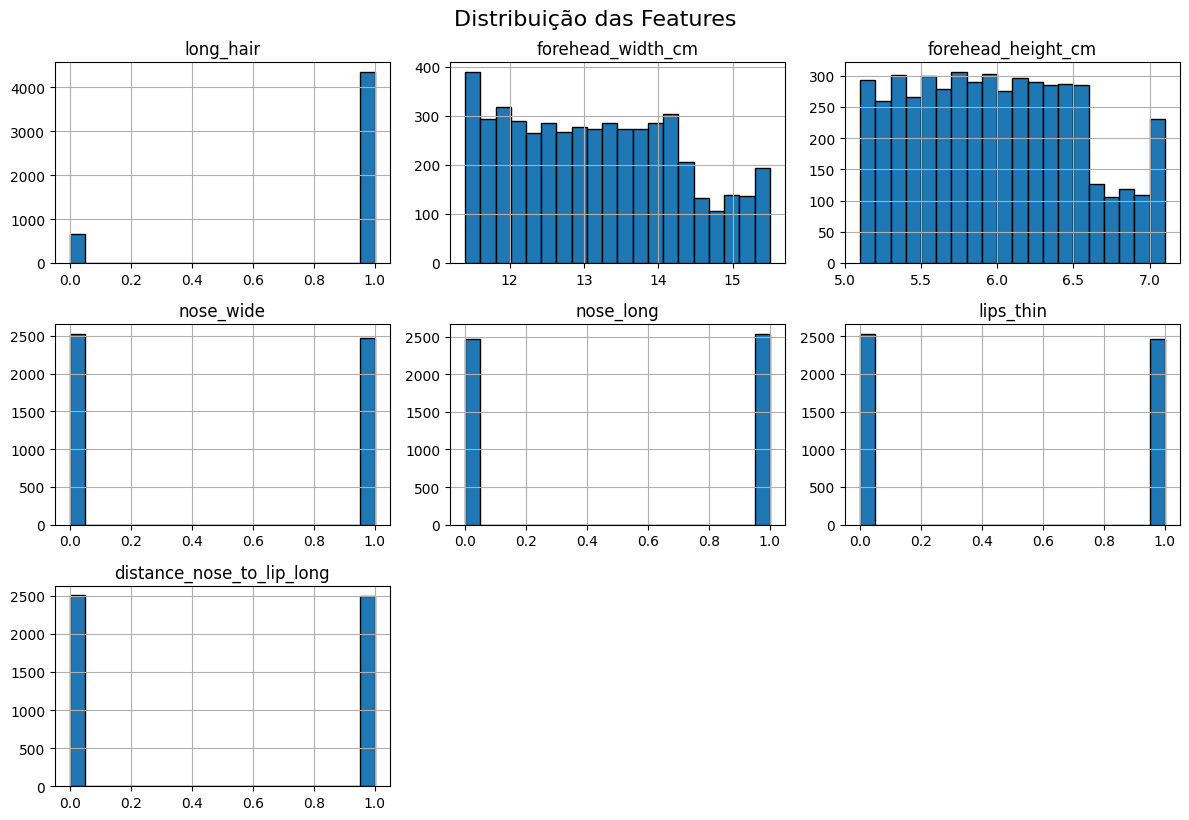

In [ ]:
# Features distribution
gender_classification_df.drop(columns=["gender"]).hist(bins=20, figsize=(12, 8), edgecolor="black")

plt.tight_layout()
plt.suptitle("Distribuição das Features", fontsize=16, y=1.02)
plt.show()

In [ ]:
# Model -> Random Forest Classifier
X = gender_classification_df.drop(columns=["gender"])
y = gender_classification_df.gender

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [ ]:
# Train Model
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

      Female       0.96      0.96      0.96       502
        Male       0.96      0.96      0.96       499

    accuracy                           0.96      1001
   macro avg       0.96      0.96      0.96      1001
weighted avg       0.96      0.96      0.96      1001



<Figure size 600x600 with 0 Axes>

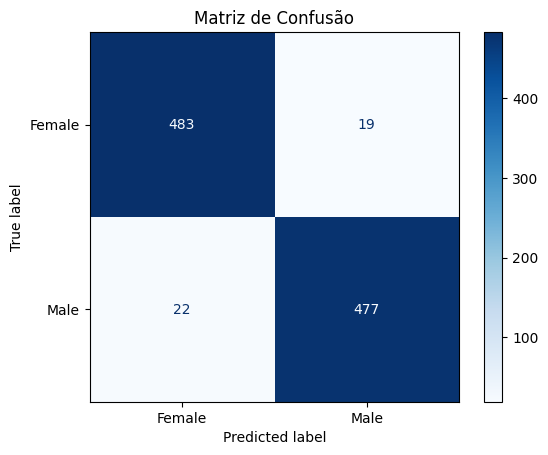

In [ ]:
# Test Model
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.show()

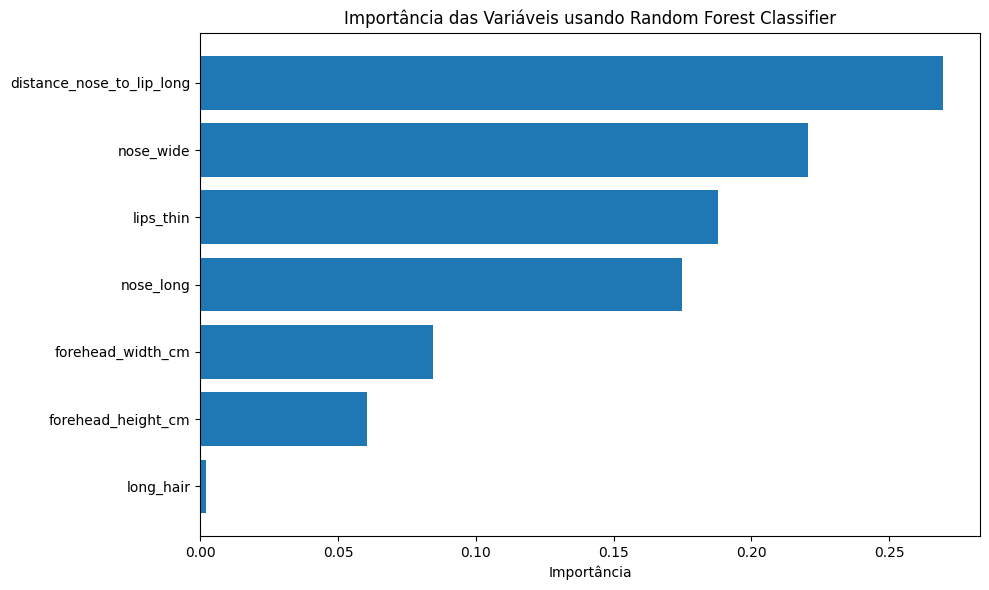

In [ ]:
# Features Importance
importances = clf.feature_importances_
features = X.columns

sorted_idx = np.argsort(importances)[::-1]
sorted_features = features[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Importância")
plt.title("Importância das Variáveis usando Random Forest Classifier")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **- Modelo usando LLM (OpenAI)**

In [ ]:
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

response = client.responses.create(
    model="gpt-4.1",
    input="Me diga em um parágrafo como você reconheceria \
    um homem ou mulher, baseado apenas nas seguintes informações: \
    cabelo longo (1=sim,0=não), largura e altura da testa (em cm), \
    nariz longo (1,0), nariz comprido (1,0), labios finos (1,0) \
    distância grande entre nariz e lábios (1,0)."
)

print(response.output_text)


Para reconhecer se uma pessoa é homem ou mulher baseado nesses atributos, eu avaliaria alguns padrões típicos de características faciais. Mulheres tendem a ter cabelo longo com mais frequência, testa ligeiramente mais estreita e menos alta, nariz menos longo e comprido, lábios menos finos e a distância entre o nariz e os lábios geralmente menor. Homens, por outro lado, costumam ter testa mais larga e alta, nariz mais longo e comprido, lábios mais finos e a distância entre o nariz e os lábios maior. Assim, se os valores indicarem cabelo longo, testa e nariz menores, lábios menos finos e distância menor entre nariz e lábios, a tendência é que a pessoa seja mulher; caso contrário, é mais provável ser homem. Porém, essas características não garantem precisão absoluta, pois há sobreposição entre os sexos.


**Resposta ao prompt acima:**

Com base apenas nessas características, eu analisaria alguns padrões geralmente associados a homens e mulheres, embora não sejam regras absolutas. Por exemplo, cabelo longo é mais comum entre mulheres, então o valor 1 para essa variável pode indicar maior chance de ser mulher. Testas mais largas e altas tendem a ser mais frequentes em homens, mas há muita variação individual. Nariz longo e comprido, assim como lábios finos e grande distância entre nariz e lábios, são traços faciais que costumam ser mais marcantes em homens, enquanto mulheres geralmente têm narizes menores, lábios mais cheios e menor distância entre nariz e boca. Assim, se a maioria das características apresentar valores associados ao padrão feminino (cabelo longo, testa mais estreita ou baixa, nariz pequeno, lábios grossos, distância pequena entre nariz e lábios), eu classificaria como mulher; caso contrário, como homem. No entanto, essas classificações são apenas aproximações estatísticas e podem variar muito entre indivíduos.

In [ ]:
# Create a subset of test dataset
subset_size = 100
X_test_str = X_test.head(subset_size).to_string(index=False, header=False)
features_str = X_test.columns.to_list()

# Construct the prompt for the OpenAI API
prompt = \
f"""
Based on the following features, predict the gender (male=1, female=0) for each person below (one per line) - features {features_str}:.
{X_test_str}
Respond only with 1 for male or 0 for female and put all responses in a list (separated by single space).
"""

try:
    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[
            {"role": "system", "content": f"You are a gender classification assistant and must use this list of features: {features_str}."},
            {"role": "user", "content": prompt}
        ],
        max_tokens=None
    )

    pred_text = response.choices[0].message.content

except Exception as e:
    print(f"An error occurred: {e}")

100
              precision    recall  f1-score   support

      Female       0.60      0.42      0.49        50
        Male       0.55      0.72      0.63        50

    accuracy                           0.57       100
   macro avg       0.58      0.57      0.56       100
weighted avg       0.58      0.57      0.56       100



<Figure size 600x600 with 0 Axes>

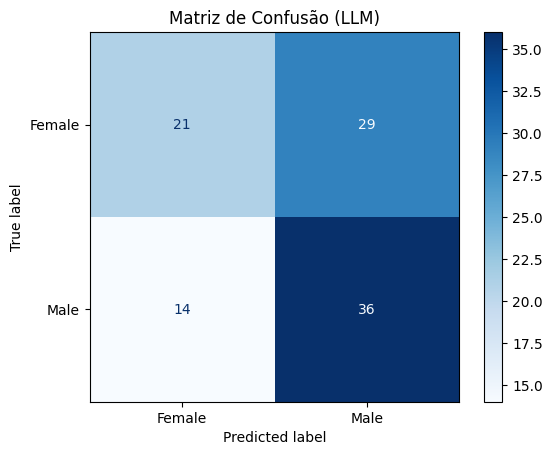

In [ ]:
# Check accuracy of predictions
openai_y_pred = np.array([int(item) for item in pred_text.split()])
print(len(openai_y_pred))

print(classification_report(y_test[:subset_size], openai_y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test[:subset_size], openai_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão (LLM)")
plt.show()
